In [ ]:
## 1.	Write a program to implement a preprocessing pipeline using Pipeline and ColumnTransformer.

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Preprocessing pipeline
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, [0,1,2,3])
])

# Full pipeline (preprocessing + model)
model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression())
])

# Train
model_pipeline.fit(X_train, y_train)

# Predict
y_pred = model_pipeline.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9


In [ ]:
## 2.	Write a program to implement data preprocessing using ColumnTransformer for mixed data types.

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Load data
data = load_iris()
X = data.data
y = data.target

# Add fake categorical column
cat = np.array(['A','B','C'] * 50).reshape(-1,1)
X = np.hstack((X, cat))

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), [0,1,2,3]),
    ('cat', OneHotEncoder(), [4])
])

# Full pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression())
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


In [ ]:
## 3.	Write a program to remove outliers using the IQR (Interquartile Range) method.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Load data
data = load_iris()
X = data.data
y = data.target

# IQR method
Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = np.all((X >= lower) & (X <= upper), axis=1)

X_clean = X[mask]
y_clean = y[mask]

print("After cleaning:", X_clean.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

After cleaning: (146, 4)
Accuracy: 1.0


In [ ]:
import pandas as pd

# Create data
data = {
    'Name': ['Rahul', 'Amit', 'Neha'],
    'Marks': [85, 90, 88]
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv('data.csv', index=False)

In [ ]:
## 4.	Write a Python program to read a .csv file and display the first 5 rows.

import pandas as pd

# Read file
df = pd.read_csv('data.csv')

# Show first 5 rows
print(df.head())

    Name  Marks
0  Rahul     85
1   Amit     90
2   Neha     88


In [ ]:
import xml.etree.ElementTree as ET

# Root
root = ET.Element("students")

# Child 1
s1 = ET.SubElement(root, "student")
name1 = ET.SubElement(s1, "name")
name1.text = "Rahul"

# Child 2
s2 = ET.SubElement(root, "student")
name2 = ET.SubElement(s2, "name")
name2.text = "Amit"

# Save XML
tree = ET.ElementTree(root)
tree.write("data.xml")

In [ ]:
## 5.	Write a program to read an XML file and extract specific tag values.

import xml.etree.ElementTree as ET

# Load XML file
tree = ET.parse('data.xml')
root = tree.getroot()

# Extract specific tag (example: 'name')
for item in root.findall('student'):
    name = item.find('name').text
    print(name)

Rahul
Amit


In [ ]:
# 6.	Write a program to read an XML file and extract specific tag values.

import xml.etree.ElementTree as ET

# Parse XML file
tree = ET.parse('data.xml')
root = tree.getroot()

# Extract values (example: name)
for student in root.findall('student'):
    print(student.find('name').text)

Rahul
Amit


In [ ]:
import pandas as pd
import json
import xml.etree.ElementTree as ET

# 1. TXT
with open('data.txt', 'w') as f:
    f.write("Hello\nThis is sample text file")

# 2. CSV
df = pd.DataFrame({
    'Name': ['Rahul', 'Amit'],
    'Marks': [85, 90]
})
df.to_csv('data.csv', index=False)

# 3. JSON
data = {
    "students": [
        {"name": "Rahul"},
        {"name": "Amit"}
    ]
}
with open('data.json', 'w') as f:
    json.dump(data, f)

# 4. XML
root = ET.Element("students")

s1 = ET.SubElement(root, "student")
ET.SubElement(s1, "name").text = "Rahul"

s2 = ET.SubElement(root, "student")
ET.SubElement(s2, "name").text = "Amit"

tree = ET.ElementTree(root)
tree.write("data.xml")

In [ ]:
## 7.	Write a Python program to read and display data from four different files and print the contents or summary of each. data.txt  ,  data.csv , data.json ,  data.xml.

import pandas as pd
import json
import xml.etree.ElementTree as ET

# 1. TXT
print("TXT:")
with open('data.txt', 'r') as f:
    print(f.read())

# 2. CSV
print("\nCSV:")
df = pd.read_csv('data.csv')
print(df.head())

# 3. JSON
print("\nJSON:")
with open('data.json', 'r') as f:
    data = json.load(f)
    print(data)

# 4. XML
print("\nXML:")
tree = ET.parse('data.xml')
root = tree.getroot()

for item in root:
    for child in item:
        print(child.tag, ":", child.text)

TXT:
Hello
This is sample text file

CSV:
    Name  Marks
0  Rahul     85
1   Amit     90

JSON:
{'students': [{'name': 'Rahul'}, {'name': 'Amit'}]}

XML:
name : Rahul
name : Amit


In [ ]:
## 8.	Write a program to implement the Decision Tree mode.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9666666666666667


In [ ]:
## 9.	 Write a program to implement the K-Nearest Neighbor model.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
## 10.	 Write a program to Evaluate classification performance using accuracy, precision, recall, and F1- score.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.9333333333333333
Precision: 0.9393939393939394
Recall: 0.9393939393939394
F1 Score: 0.9393939393939394


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
## 11.	Write a program to implement the Linear Regression by using the suitable dataset.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
data = load_iris()
X = data.data
y = data.target   # using target for simplicity

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Score (R²)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9425654339046072


In [ ]:
## 12.	Write a program to implement the logistic regression by using the suitable dataset.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [ ]:
## 13.	Write a program to implement the Ridge Regression by using the suitable dataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Score (R²)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.943333359296769


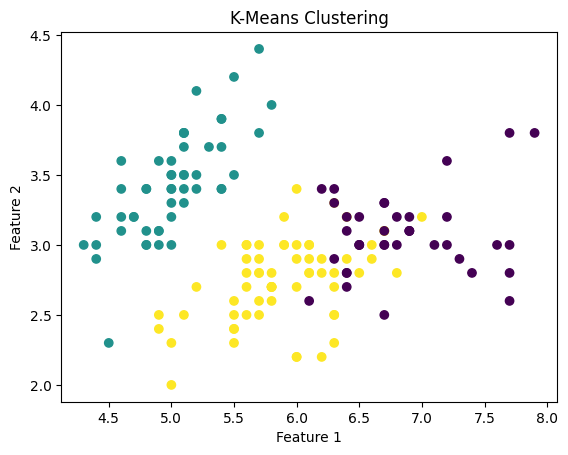

In [ ]:
## 14.	Write a program to use clustering algorithms to find patterns in data. Visualize the results using Matplotlib / Seaborn.

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load data
data = load_iris()
X = data.data

# Model
kmeans = KMeans(n_clusters=3)
y_kmeans = kmeans.fit_predict(X)

# Plot (using first 2 features)
plt.scatter(X[:,0], X[:,1], c=y_kmeans)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

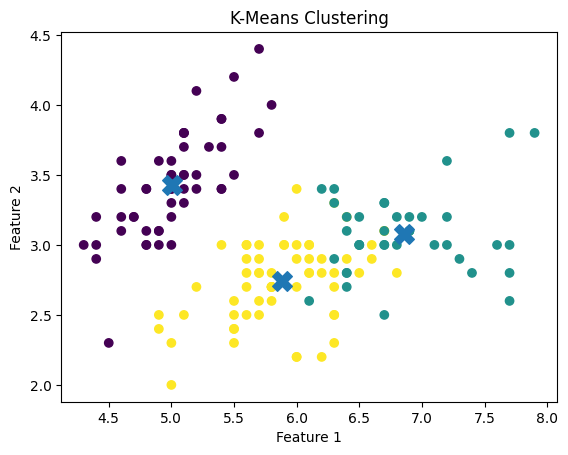

In [ ]:
## 15.	Write a program to implement K-Means Clustering algorithms, Visualize the results using Matplotlib / Seaborn.

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load data
data = load_iris()
X = data.data

# Model
kmeans = KMeans(n_clusters=3)
y_kmeans = kmeans.fit_predict(X)

# Plot clusters
plt.scatter(X[:,0], X[:,1], c=y_kmeans)

# Plot centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

In [ ]:
## 16.	Write a program to identify the most important features that contributes to the model accuracy.

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

data = load_iris()
X = data.data
y = data.target

model = DecisionTreeClassifier()
model.fit(X, y)

imp = model.feature_importances_

print("Feature 0:", imp[0])
print("Feature 1:", imp[1])
print("Feature 2:", imp[2])
print("Feature 3:", imp[3])

Feature 0: 0.026666666666666665
Feature 1: 0.0
Feature 2: 0.5507226247987118
Feature 3: 0.42261070853462157


             Feature  Importance
2  petal length (cm)    0.436130
3   petal width (cm)    0.436065
0  sepal length (cm)    0.106128
1   sepal width (cm)    0.021678


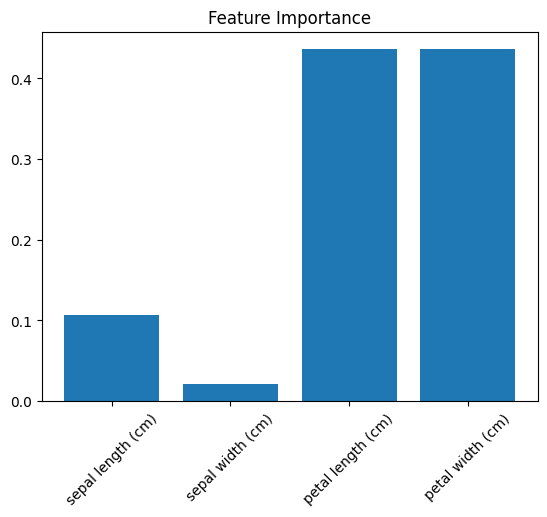

In [4]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
# Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)
# Get feature importance
importance = model.feature_importances_
# Display feature importance
feature_df = pd.DataFrame({
 'Feature': feature_names,
 'Importance': importance
})
print(feature_df.sort_values(by='Importance', ascending=False))
# Visualize feature importance
plt.bar(feature_names, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
## 17.	Write a program to Build KNN Classification model for a given dataset. Vary the number of k values as follows and compare the results:  i. 1 ii. 3 iii. 5.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# k = 1
model1 = KNeighborsClassifier(n_neighbors=1)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)
print("k=1 Accuracy:", accuracy_score(y_test, pred1))

# k = 3
model3 = KNeighborsClassifier(n_neighbors=3)
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)
print("k=3 Accuracy:", accuracy_score(y_test, pred3))

# k = 5
model5 = KNeighborsClassifier(n_neighbors=5)
model5.fit(X_train, y_train)
pred5 = model5.predict(X_test)
print("k=5 Accuracy:", accuracy_score(y_test, pred5))

k=1 Accuracy: 0.9666666666666667
k=3 Accuracy: 0.9666666666666667
k=5 Accuracy: 0.9666666666666667


In [ ]:
## 20.  Write a program to Implement Support Vector Machine for a dataset and compare the accuracy by applying the  following kernel functions:  i. Linear ii. Polynomial iii. RBF .

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Linear kernel
model1 = SVC(kernel='linear')
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)
print("Linear Accuracy:", accuracy_score(y_test, pred1))

# Polynomial kernel
model2 = SVC(kernel='poly')
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
print("Polynomial Accuracy:", accuracy_score(y_test, pred2))

# RBF kernel
model3 = SVC(kernel='rbf')
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)
print("RBF Accuracy:", accuracy_score(y_test, pred3))

Linear Accuracy: 0.9
Polynomial Accuracy: 0.9
RBF Accuracy: 0.9


In [ ]:
## 21.	Write a program to Apply logistic regression to identify whether a student will pass or fail based on his marks & study hours.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Data: [marks, study_hours]
X = np.array([
    [40, 1], [50, 2], [60, 2], [70, 3],
    [80, 4], [90, 5], [30, 1], [20, 0.5]
])

# Output: 0 = Fail, 1 = Pass
y = np.array([0, 0, 1, 1, 1, 1, 0, 0])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# New prediction
result = model.predict([[65, 3]])
print("Result:", "Pass" if result[0] == 1 else "Fail")

Accuracy: 0.5
Result: Pass


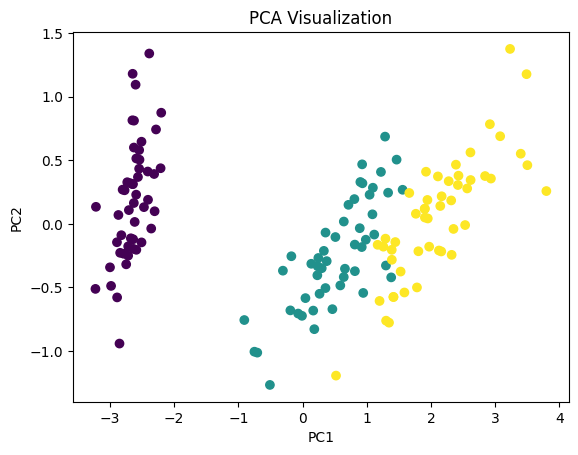

Accuracy: 0.9333333333333333


In [ ]:
## 22.	Write a program to implement Principal Component Analysis (PCA) for dimensionality reduction, visualize the reduced data and evaluate its effectiveness using a classification algorithm.

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
data = load_iris()
X = data.data
y = data.target

# Apply PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

# Split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2)

# Classification
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
## 23.	Write a program to Build a simple decision-support system for medical diagnosis using a decision tree.

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Data: [fever, cough, fatigue]
X = np.array([
    [1, 1, 1],
    [1, 1, 0],
    [0, 1, 1],
    [0, 0, 0],
    [1, 0, 1],
    [0, 1, 0]
])

# Output: 1 = Disease, 0 = No Disease
y = np.array([1, 1, 1, 0, 1, 0])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# New patient prediction
result = model.predict([[1, 1, 0]])
print("Diagnosis:", "Disease" if result[0] == 1 else "No Disease")

Accuracy: 1.0
Diagnosis: Disease


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Predict a new case (just using one sample from dataset)
result = model.predict([X[0]])

print("Diagnosis:", "Malignant" if result[0] == 0 else "Benign")

Accuracy: 0.9385964912280702
Diagnosis: Malignant


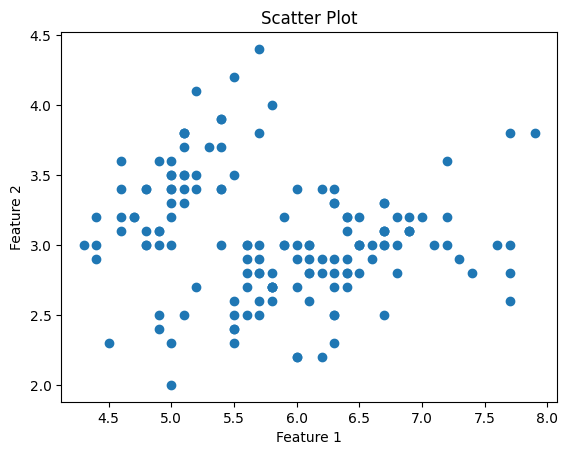

In [ ]:
## 24.	Write a Python program to visualize the relationship between LSTAT and MEDV using a scatter plot.

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load data
data = load_iris()
X = data.data

# Use 2 features
x = X[:, 0]   # sepal length
y = X[:, 1]   # sepal width

# Plot
plt.scatter(x, y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot")

plt.show()

In [ ]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_score = rf.score(X_test, y_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_score = lr.score(X_test, y_test)

# Results
print("Random Forest Accuracy:", rf_score)
print("Linear Regression Score:", lr_score)

Random Forest Accuracy: 0.9666666666666667
Linear Regression Score: 0.9263886551664866


In [ ]:
#### 25.	Write a program to design a predictive model using Decision Tree or Random Forest for the same dataset and compare results with Linear Regression.
## 25. Predictive model + comparison + user input (final version)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -------- Random Forest --------
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# -------- Linear Regression --------
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)

# -------- Comparison --------
print("Random Forest Accuracy:", rf_accuracy)
print("Linear Regression R2 Score:", lr_r2)

# -------- User Input --------
print("\nEnter new flower data:")

sl = float(input("Sepal Length: "))
sw = float(input("Sepal Width: "))
pl = float(input("Petal Length: "))
pw = float(input("Petal Width: "))

user_data = [[sl, sw, pl, pw]]

# -------- Predictions --------
rf_result = rf.predict(user_data)
lr_result = lr.predict(user_data)

# Convert Linear Regression output → class label
lr_class = int(round(lr_result[0]))
lr_class = max(0, min(lr_class, 2))  # keep within valid range

# -------- Final Output --------
print("\nRandom Forest Prediction:", data.target_names[rf_result[0]])
print("Linear Regression Prediction:", data.target_names[lr_class])

Random Forest Accuracy: 0.9333333333333333
Linear Regression R2 Score: 0.9039985971382295

Enter new flower data:
Sepal Length: 6.5
Sepal Width: 3
Petal Length: 5.5
Petal Width: 2

Random Forest Prediction: virginica
Linear Regression Prediction: virginica


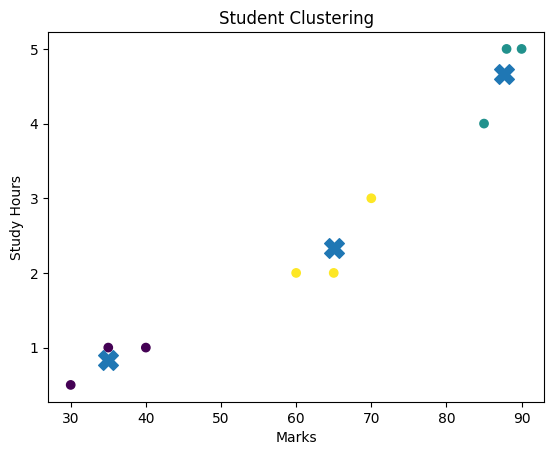

In [ ]:
## 26.	 Write a program to Perform clustering on student performance dataset to group students by learning patterns.

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Data: [marks, study_hours]
X = np.array([
    [90, 5], [85, 4], [88, 5],
    [60, 2], [65, 2], [70, 3],
    [40, 1], [35, 1], [30, 0.5]
])

# Model
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)

# Centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)

plt.xlabel("Marks")
plt.ylabel("Study Hours")
plt.title("Student Clustering")

plt.show()

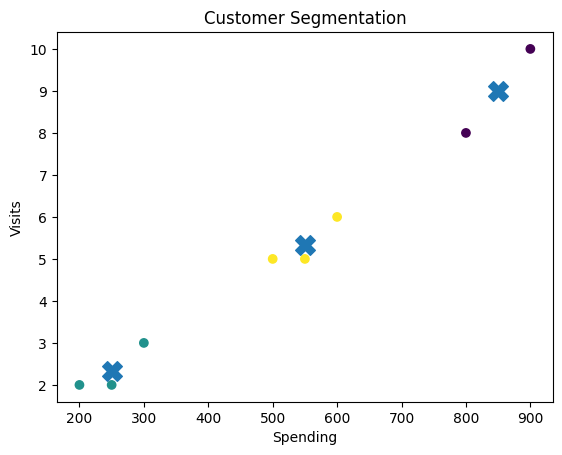

In [ ]:
## 27.	Write a program to design a clustering-based system to segment users for an e-commerce marketing strategy

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Data: [annual_spend, visits]
X = np.array([
    [500, 5], [600, 6], [550, 5],
    [200, 2], [250, 2], [300, 3],
    [800, 8], [850, 9], [900, 10]
])

# Model
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)

# Centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)

plt.xlabel("Spending")
plt.ylabel("Visits")
plt.title("Customer Segmentation")

plt.show()